## Ranking model: predicting which stocks should be ranked highest each day

In this section, I build a ranking model that orders stocks from the most promising to the least promising in terms of **next-day return**.

I use a **pointwise ranking approach**:
- first, train one generic model to predict `Target_Return_1d`
- then, for each date, sort stocks by the predicted return in descending order

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from pathlib import Path
from sklearn.model_selection import ParameterGrid
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
data_path = Path("../01_data/raw/df_eda.csv")
df_model = pd.read_csv(data_path)

print("Shape:", df_model.shape)
df_model.head()

Shape: (19836, 17)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,0.001729,Monday,January
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL,0.001729,NaN,NaN,NaN,NaN,0.219098,-0.015906,Tuesday,January
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL,-0.015906,NaN,NaN,NaN,NaN,-0.082646,-0.001849,Wednesday,January
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016028,NaN,NaN,NaN,-0.135882,0.006648,Thursday,January
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL,0.006648,-0.011195,NaN,NaN,NaN,-0.061871,-0.008821,Friday,January


The ranking target is still the next-day return, because the final ranking should\
reflect which stock is expected to have the highest daily gain.

In [3]:
ranking_df = df_model.copy()

ranking_df["Date"] = pd.to_datetime(ranking_df["Date"])
ranking_df = ranking_df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

target_col = "Target_Return_1d"

candidate_numeric_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d"
]

candidate_categorical_features = ["Ticker", "Weekday", "Month"]

numeric_features = [col for col in candidate_numeric_features if col in ranking_df.columns]
categorical_features = [col for col in candidate_categorical_features if col in ranking_df.columns]

# avoid duplicate Ticker column
feature_categorical_features = [col for col in categorical_features if col != "Ticker"]

required_cols = ["Date", "Ticker", target_col] + numeric_features + feature_categorical_features
ranking_df = ranking_df[required_cols].copy()

ranking_df = ranking_df.dropna(subset=[target_col]).copy()

# Keep only dates with at least 2 stocks available
valid_dates = (
    ranking_df.groupby("Date")["Ticker"]
    .nunique()
    .loc[lambda s: s >= 2]
    .index
)

ranking_df = ranking_df[ranking_df["Date"].isin(valid_dates)].copy()

ranking_df["Actual_Rank"] = (
    ranking_df.groupby("Date")[target_col]
    .rank(method="first", ascending=False)
)

print("Shape:", ranking_df.shape)
print("Number of ranking dates:", ranking_df["Date"].nunique())
ranking_df.head()

Shape: (19831, 17)
Number of ranking dates: 4086


,Date,Ticker,Target_Return_1d,Open,High,Low,Close,Volume,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Weekday,Month,Actual_Rank
0,2010-01-04,AAPL,0.001729,7.622500,7.660714,7.585000,7.643214,493729600,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,2.0
1,2010-01-04,AMZN,0.005900,6.812500,6.830500,6.657000,6.695000,151998000,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,1.0
2,2010-01-04,GOOGL,-0.004404,15.689439,15.753504,15.621622,15.684434,78169752,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,4.0
3,2010-01-04,MSFT,0.000323,30.620001,31.100000,30.590000,30.950001,38409100,NaN,NaN,NaN,NaN,NaN,NaN,Monday,January,3.0
4,2010-01-05,AAPL,-0.015906,7.664286,7.699643,7.616071,7.656429,601904800,0.001729,NaN,NaN,NaN,NaN,0.219098,Tuesday,January,2.0


The ranking dataset contains **19,831 observations across 4,086 trading dates**,\
Each row represents one stock on one date, while `Actual_Rank` shows the true daily\
ordering based on the next-day return.

### Time-based train

Because this is financial time-series data, I split by time rather than randomly.  
This avoids leakage from the future into the past and makes the ranking task\
closer to a real forecasting setup.

In [4]:
unique_dates = np.array(sorted(ranking_df["Date"].unique()))

n_dates = len(unique_dates)
train_cut = int(n_dates * 0.70)
val_cut = int(n_dates * 0.85)

train_dates = unique_dates[:train_cut]
val_dates = unique_dates[train_cut:val_cut]
test_dates = unique_dates[val_cut:]

train_df = ranking_df[ranking_df["Date"].isin(train_dates)].copy()
val_df = ranking_df[ranking_df["Date"].isin(val_dates)].copy()
test_df = ranking_df[ranking_df["Date"].isin(test_dates)].copy()

for name, part in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(
        f"{name}: {part['Date'].min().date()} -> {part['Date'].max().date()} | "
        f"rows={len(part)} | dates={part['Date'].nunique()}"
    )

Train: 2010-01-04 -> 2021-05-13 | rows=13701 | dates=2860
Validation: 2021-05-14 -> 2023-10-19 | rows=3065 | dates=613
Test: 2023-10-20 -> 2026-04-01 | rows=3065 | dates=613


I will use:
- training set for fitting the models
- validation set for model selection
- test set for final evaluation

### Ranking

During ranking what matters is whether the model places the best opportunities near the top.

I use three ranking-oriented metrics:
- **NDCG@3**: checks whether the best stocks are placed near the top 3 positions
- **Spearman correlation**: measures how well the predicted order matches the true order
- **Top-1 hit rate**: shows how often the model correctly identifies the single best stock of the day

In [5]:
def dcg_at_k(relevance, k):
    relevance = np.asarray(relevance)[:k]
    if len(relevance) == 0:
        return np.nan
    discounts = np.log2(np.arange(2, len(relevance) + 2))
    return np.sum((2**relevance - 1) / discounts)


def evaluate_ranking(df, score_col, target_col="Target_Return_1d", k=3):
    daily_rows = []

    for date, g in df.groupby("Date"):
        g = g.dropna(subset=[score_col, target_col]).copy()

        if len(g) < 2:
            continue

        g = g.sort_values(score_col, ascending=False).reset_index(drop=True)
        n = len(g)

        # Convert actual ranks into positive relevance scores for NDCG
        actual_rank = g[target_col].rank(method="first", ascending=False)
        relevance = (n - actual_rank + 1).astype(int).to_numpy()

        dcg = dcg_at_k(relevance, min(k, n))
        idcg = dcg_at_k(np.sort(relevance)[::-1], min(k, n))
        ndcg = dcg / idcg if idcg > 0 else np.nan

        spearman = g[[score_col, target_col]].corr(method="spearman").iloc[0, 1]

        predicted_top = g.iloc[0]["Ticker"]
        actual_top = g.loc[g[target_col].idxmax(), "Ticker"]
        top1_hit = int(predicted_top == actual_top)

        daily_rows.append({
            "Date": date,
            "NDCG@3": ndcg,
            "Spearman": spearman,
            "Top1_Hit": top1_hit,
            "Predicted_Top1": predicted_top,
            "Actual_Top1": actual_top,
            "Top1_Actual_Return": g.iloc[0][target_col],
            "Best_Actual_Return": g[target_col].max(),
            "Universe_Mean_Return": g[target_col].mean()
        })

    daily_eval = pd.DataFrame(daily_rows)

    summary = pd.DataFrame({
        "Metric": ["NDCG@3", "Spearman", "Top1_Hit", "Top1_Actual_Return", "Best_Actual_Return", "Universe_Mean_Return"],
        "Value": [
            daily_eval["NDCG@3"].mean(),
            daily_eval["Spearman"].mean(),
            daily_eval["Top1_Hit"].mean(),
            daily_eval["Top1_Actual_Return"].mean(),
            daily_eval["Best_Actual_Return"].mean(),
            daily_eval["Universe_Mean_Return"].mean()
        ]
    })

    return daily_eval, summary

### 1st try

Before using machine learning, I create a simple benchmark:
rank stocks by today's `Return_1d`.\
This is a simple baseline\
It is useful because a more complex model should beat a very simple one

In [6]:
baseline_score_col = "Return_1d"

val_baseline_daily, val_baseline_summary = evaluate_ranking(
    val_df,
    score_col=baseline_score_col,
    target_col=target_col
)

test_baseline_daily, test_baseline_summary = evaluate_ranking(
    test_df,
    score_col=baseline_score_col,
    target_col=target_col
)

print("Validation baseline:")
display(val_baseline_summary)

print("Test baseline:")
display(test_baseline_summary)

Validation baseline:


,Metric,Value
0,NDCG@3,0.539347
1,Spearman,-0.012072
2,Top1_Hit,0.176183
3,Top1_Actual_Return,-0.000088
4,Best_Actual_Return,0.014453
5,Universe_Mean_Return,0.000436


Test baseline:


,Metric,Value
0,NDCG@3,0.566858
1,Spearman,0.037194
2,Top1_Hit,0.251223
3,Top1_Actual_Return,0.001835
4,Best_Actual_Return,0.015442
5,Universe_Mean_Return,0.000990


The baseline shows **weak ranking performance overall**.  
Both validation and test **Spearman correlations are close to zero**, which means\
yesterday’s return does not align well with the true next-day stock ordering.

The **Top-1 hit rate** is also fairly low, so the baseline does not often get the best stock of the day.

### 2nd try

I compare three pointwise models:
- **Linear Regression**: a simple linear benchmark
- **Random Forest**: captures nonlinear patterns and interactions
- **LightGBM**: usually well performing on tabular data

I keep the same feature set and preprocessing for all models so the comparison is fair.

I choose the final model based on validation ranking quality, not just on regression logic.

In [ ]:
feature_cols = numeric_features + feature_categorical_features

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, feature_categorical_features)
])

preprocessor.set_output(transform="pandas")

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMRegressor was fitted with feature names"
)

param_grids = {
    "Linear Regression": [{}],
    "Random Forest": list(ParameterGrid({
        "n_estimators": [200, 300],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [3, 5]
    })),
    "LightGBM": list(ParameterGrid({
        "n_estimators": [100, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "num_leaves": [15, 31],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    }))
}

best_models = {}
all_tuning_results = []
validation_results = []

for model_name, grid in param_grids.items():
    best_row = None
    best_pipe = None
    best_score = -np.inf

    for params in grid:
        if model_name == "Linear Regression":
            model = LinearRegression()

        elif model_name == "Random Forest":
            model = RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
                **params
            )

        elif model_name == "LightGBM":
            model = LGBMRegressor(
                objective="regression",
                random_state=42,
                verbose=-1,
                **params
            )

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(train_df[feature_cols], train_df[target_col])

        val_scored = val_df.copy()
        val_scored["Predicted_Score"] = pipe.predict(val_df[feature_cols])

        _, val_summary = evaluate_ranking(
            val_scored,
            score_col="Predicted_Score",
            target_col=target_col
        )

        row = val_summary.set_index("Metric")["Value"].to_dict()
        row["Model"] = model_name
        row["Params"] = params
        all_tuning_results.append(row)

        current_score = row["NDCG@3"]

        if current_score > best_score:
            best_score = current_score
            best_row = row
            best_pipe = pipe

    validation_results.append(best_row)
    best_models[model_name] = {
        "pipeline": best_pipe,
        "params": best_row["Params"]
    }

validation_comparison = (
    pd.DataFrame(validation_results)
    .set_index("Model")
    .sort_values(["NDCG@3", "Top1_Hit", "Spearman"], ascending=False)
)

all_tuning_results_df = (
    pd.DataFrame(all_tuning_results)
    .sort_values(["NDCG@3", "Top1_Hit", "Spearman"], ascending=False)
    .reset_index(drop=True)
)

validation_comparison

,NDCG@3,Spearman,Top1_Hit,Top1_Actual_Return,Best_Actual_Return,Universe_Mean_Return,Params
Model,,,,,,,
Linear Regression,0.564473,0.013051,0.215334,0.001393,0.014453,0.000436,{}
Random Forest,0.560861,-0.000021,0.230016,0.000907,0.014453,0.000436,"{'max_depth': 5, 'min_samples_leaf': 3, 'n_est..."
LightGBM,0.556787,0.001675,0.218597,0.000666,0.014453,0.000436,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."


After hyperparameter tuning, **Linear Regression still remained the strongest model overall on the validation set**.  

## 3rd test

After choosing the strongest model on the validation set,\
I use it on both training and validation data.

In [8]:
best_model_name = validation_comparison.index[0]
best_model_params = best_models[best_model_name]["params"]

if best_model_name == "Linear Regression":
    final_estimator = LinearRegression()

elif best_model_name == "Random Forest":
    final_estimator = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **best_model_params
    )

elif best_model_name == "LightGBM":
    final_estimator = LGBMRegressor(
        objective="regression",
        random_state=42,
        verbose=-1,
        **best_model_params
    )

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_estimator)
])

train_val_df = pd.concat([train_df, val_df], axis=0).sort_values(["Date", "Ticker"])

final_model.fit(train_val_df[feature_cols], train_val_df[target_col])

test_scored = test_df.copy()
test_scored["Predicted_Score"] = final_model.predict(test_df[feature_cols])

test_model_daily, test_model_summary = evaluate_ranking(
    test_scored,
    score_col="Predicted_Score",
    target_col=target_col
)

print("Chosen model:", best_model_name)
print("Best params:", best_model_params)
display(test_model_summary)

Chosen model: Linear Regression
Best params: {}


,Metric,Value
0,NDCG@3,0.549416
1,Spearman,-0.003426
2,Top1_Hit,0.197390
3,Top1_Actual_Return,0.001290
4,Best_Actual_Return,0.015442
5,Universe_Mean_Return,0.000990


The ranking model achieved **moderate NDCG@3**, but its **Spearman correlation is still close to zero**,\
which means the overall daily stock ordering remains difficult to predict. The model identifies the best\
stock of the day rarely, so ranking precision is still fairly weak.

## Compare models

This comparison shows whether the machine learning model improves:
- the overall ordering of stocks
- the quality of the top-ranked ideas
- the chance of correctly selecting the best stock of the day

In [9]:
comparison_df = pd.DataFrame({
    "Naive momentum (Return_1d)": test_baseline_summary.set_index("Metric")["Value"],
    f"Final model ({best_model_name})": test_model_summary.set_index("Metric")["Value"]
}).T

comparison_df

Metric,NDCG@3,Spearman,Top1_Hit,Top1_Actual_Return,Best_Actual_Return,Universe_Mean_Return
Naive momentum (Return_1d),0.566858,0.037194,0.251223,0.001835,0.015442,0.00099
Final model (Linear Regression),0.549416,-0.003426,0.197390,0.001290,0.015442,0.00099


### Baseline vs final ranking model

The final Linear Regression model did **not outperform the naive momentum baseline** on the test set.  
The baseline achieved better **NDCG@3**, **Spearman correlation**, **Top-1 hit rate**,\
and a higher realized return for the top-ranked stock.

This suggests that, in the current setup, **recent return alone was a stronger ranking signal** than the full feature-based model.  
Overall, the ranking task remains difficult, and the current machine learning model does not yet add value over the simple baseline.

## Inspect one daily ranking example

Besides summary metrics, it is useful to look at one date directly.  
This makes it easier to see how the predicted ranking compares with the actual ranking.

In [10]:
sample_date = test_scored["Date"].drop_duplicates().iloc[0]

sample_ranking = (
    test_scored.loc[test_scored["Date"] == sample_date, ["Date", "Ticker", "Predicted_Score", target_col]]
    .sort_values("Predicted_Score", ascending=False)
    .reset_index(drop=True)
)

sample_ranking["Predicted_Rank"] = np.arange(1, len(sample_ranking) + 1)
sample_ranking["Actual_Rank"] = (
    sample_ranking[target_col]
    .rank(method="first", ascending=False)
    .astype(int)
)

sample_ranking

,Date,Ticker,Predicted_Score,Target_Return_1d,Predicted_Rank,Actual_Rank
0,2023-10-20,AAPL,0.002413,0.000694,1,5
1,2023-10-20,AMZN,0.002344,0.011105,2,2
2,2023-10-20,GOOGL,0.002137,0.006637,3,4
3,2023-10-20,MSFT,0.000570,0.008112,4,3
4,2023-10-20,META,0.000462,0.017366,5,1


## Visualize ranking performance

I use two plots:
- a bar chart for the main ranking metrics
- a rolling plot of the realized return of the top-ranked stock

The first plot summarizes ranking quality, while the second helps show whether the model's top picks are producing better realized returns than a simple baseline or the average stock.

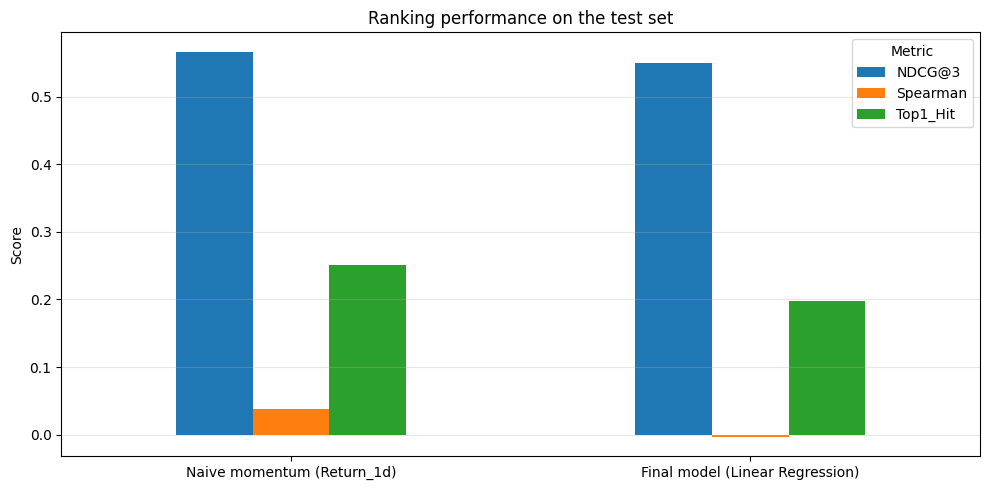

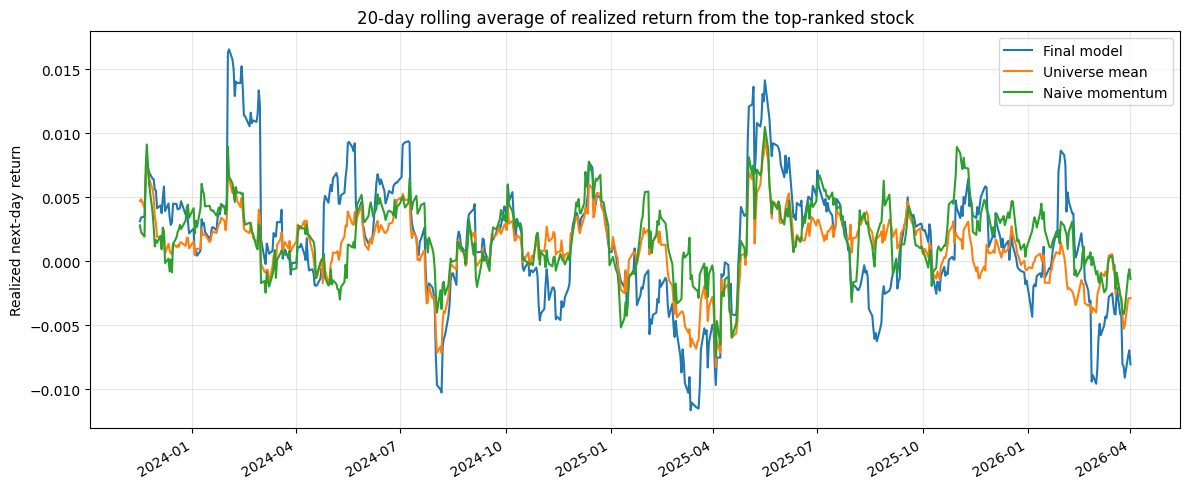

In [11]:
# Bar chart for key ranking metrics
plot_metrics = ["NDCG@3", "Spearman", "Top1_Hit"]

comparison_df[plot_metrics].plot(kind="bar", figsize=(10, 5))
plt.title("Ranking performance on the test set")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Rolling realized return of the top-ranked stock
baseline_plot = test_baseline_daily[["Date", "Top1_Actual_Return"]].rename(
    columns={"Top1_Actual_Return": "Naive momentum"}
)

model_plot = test_model_daily[["Date", "Top1_Actual_Return", "Universe_Mean_Return"]].rename(
    columns={
        "Top1_Actual_Return": "Final model",
        "Universe_Mean_Return": "Universe mean"
    }
)

rolling_plot_df = (
    model_plot.merge(baseline_plot, on="Date", how="inner")
    .sort_values("Date")
    .set_index("Date")
    .rolling(20)
    .mean()
)

rolling_plot_df.plot(figsize=(12, 5))
plt.title("20-day rolling average of realized return from the top-ranked stock")
plt.ylabel("Realized next-day return")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Overview

In this notebook, I built a ranking framework that predicts **next-day stock returns** and\
then ranks stocks within each trading date from the highest expected gain to the lowest.\
I used a **pointwise ranking approach**, where return prediction is converted into a daily\
ranking, and evaluated it with **NDCG@3**, **Spearman correlation**, and **Top-1 hit rate**.

The results show that ranking stock performance is a difficult task in this setup.  

The charts confirm this result visually: the baseline had slightly better ranking metrics,\
while the rolling top-pick returns show that the final model was more volatile and less\
consistent over time.  
Overall, **stocks prices hard to predict**